In [1]:
import pandas as pd
import numpy as np

In [2]:
coef_df = pd.read_csv("/Users/julialukens/Documents/repos/6.C511_FairnessProject/model/TunedOutputs_2Incomes/all_weights.csv")

In [3]:
# Normalize

for col in ["cdc_weight", "unconstrained_weight", "constrained_weight"]:
    coef_df[col.replace("_coef", "_weight")] = (
        coef_df[col] / coef_df[col].abs().sum()
    )

In [4]:
# Compare unconstrained v. CDC

coef_df["unconstrained_minus_cdc"] = (
    coef_df["unconstrained_weight"] - coef_df["cdc_weight"]
)

coef_df["abs_unconstrained_minus_cdc"] = (
    coef_df["unconstrained_minus_cdc"].abs()
)

In [5]:
# Compare unconstrained v. constrained

coef_df["constrained_minus_unconstrained"] = (
    coef_df["constrained_weight"] - coef_df["unconstrained_weight"]
)

coef_df["abs_constrained_minus_unconstrained"] = (
    coef_df["constrained_minus_unconstrained"].abs()
)

In [6]:
coef_df.sort_values(
    "abs_constrained_minus_unconstrained",
    ascending=False
).head(10)

,indicator,cdc_weight,unconstrained_weight,constrained_weight,unconstrained_minus_cdc,abs_unconstrained_minus_cdc,constrained_minus_unconstrained,abs_constrained_minus_unconstrained
20,PR_NOVEH,0.035696,-0.040299,-0.154941,-0.075995,0.075995,-0.114642,0.114642
14,PR_DISABL,0.024998,0.002919,-0.085357,-0.022078,0.022078,-0.088276,0.088276
7,PR_MNTHL,0.041696,0.134360,0.052073,0.092665,0.092665,-0.082287,0.082287
10,PR_UNEMP,0.024998,0.047941,0.129773,0.022943,0.022943,0.081833,0.081833
21,PR_MOBILE,0.035696,-0.016029,0.062970,-0.051725,0.051725,0.078998,0.078998
18,PR_IMPERV,0.035696,0.116758,0.049843,0.081062,0.081062,-0.066915,0.066915
4,PR_DIABETES,0.041696,0.084660,0.020112,0.042964,0.042964,-0.064548,0.064548
12,PR_ISO,0.024998,-0.039318,0.014962,-0.064316,0.064316,0.054280,0.054280
19,PR_TREEC,0.035696,0.068656,0.016402,0.032960,0.032960,-0.052254,0.052254
8,PR_UNINSUR,0.024998,0.015902,0.063104,-0.009096,0.009096,0.047202,0.047202


In [7]:
# create ranking

for col in ["cdc_weight", "unconstrained_weight", "constrained_weight"]:
    coef_df[col.replace("_weight", "_rank")] = (
        coef_df[col].abs().rank(ascending=False)
    )

coef_df["rank_change_constraint"] = (
    coef_df["constrained_rank"] - coef_df["unconstrained_rank"]
).abs()

coef_df.sort_values("rank_change_constraint", ascending=False).head(10)


,indicator,cdc_weight,unconstrained_weight,constrained_weight,unconstrained_minus_cdc,abs_unconstrained_minus_cdc,constrained_minus_unconstrained,abs_constrained_minus_unconstrained,cdc_rank,unconstrained_rank,constrained_rank,rank_change_constraint
14,PR_DISABL,0.024998,0.002919,-0.085357,-0.022078,0.022078,-0.088276,0.088276,20.5,24.0,3.0,21.0
8,PR_UNINSUR,0.024998,0.015902,0.063104,-0.009096,0.009096,0.047202,0.047202,20.5,21.0,5.0,16.0
21,PR_MOBILE,0.035696,-0.016029,0.062970,-0.051725,0.051725,0.078998,0.078998,12.0,20.0,6.0,14.0
4,PR_DIABETES,0.041696,0.084660,0.020112,0.042964,0.042964,-0.064548,0.064548,5.5,3.0,15.0,12.0
19,PR_TREEC,0.035696,0.068656,0.016402,0.032960,0.032960,-0.052254,0.052254,12.0,5.0,17.0,12.0
9,PR_POV,0.024998,0.026844,0.064188,0.001846,0.001846,0.037344,0.037344,20.5,15.0,4.0,11.0
3,PR_OBS,0.041696,-0.044179,-0.014031,-0.085875,0.085875,0.030149,0.030149,5.5,8.0,19.0,11.0
23,PR_OZONE,0.035696,0.071048,0.029334,0.035352,0.035352,-0.041715,0.041715,12.0,4.0,13.0,9.0
20,PR_NOVEH,0.035696,-0.040299,-0.154941,-0.075995,0.075995,-0.114642,0.114642,12.0,10.0,1.0,9.0
6,PR_ASTHMA,0.041696,0.031849,0.005324,-0.009847,0.009847,-0.026525,0.026525,5.5,14.0,22.0,8.0


In [8]:
# similarity between the 3

from scipy.stats import spearmanr, pearsonr
from sklearn.metrics.pairwise import cosine_similarity

weight_cols = ["cdc_weight", "unconstrained_weight", "constrained_weight"]

def compare_vectors(a, b):
    x = coef_df[a].values
    y = coef_df[b].values
    
    return {
        "cosine_similarity": cosine_similarity(
            x.reshape(1, -1),
            y.reshape(1, -1)
        )[0, 0],
        "pearson_corr": pearsonr(x, y).statistic,
        "spearman_corr": spearmanr(x, y).statistic
    }

comparisons = pd.DataFrame({
    "CDC vs unconstrained": compare_vectors("cdc_weight", "unconstrained_weight"),
    "CDC vs constrained": compare_vectors("cdc_weight", "constrained_weight"),
    "Unconstrained vs constrained": compare_vectors("unconstrained_weight", "constrained_weight")
}).T

print(comparisons)


                              cosine_similarity  pearson_corr  spearman_corr
CDC vs unconstrained                   0.359587      0.066444       0.143427
CDC vs constrained                     0.193621     -0.005776      -0.119522
Unconstrained vs constrained           0.559444      0.522847       0.644615


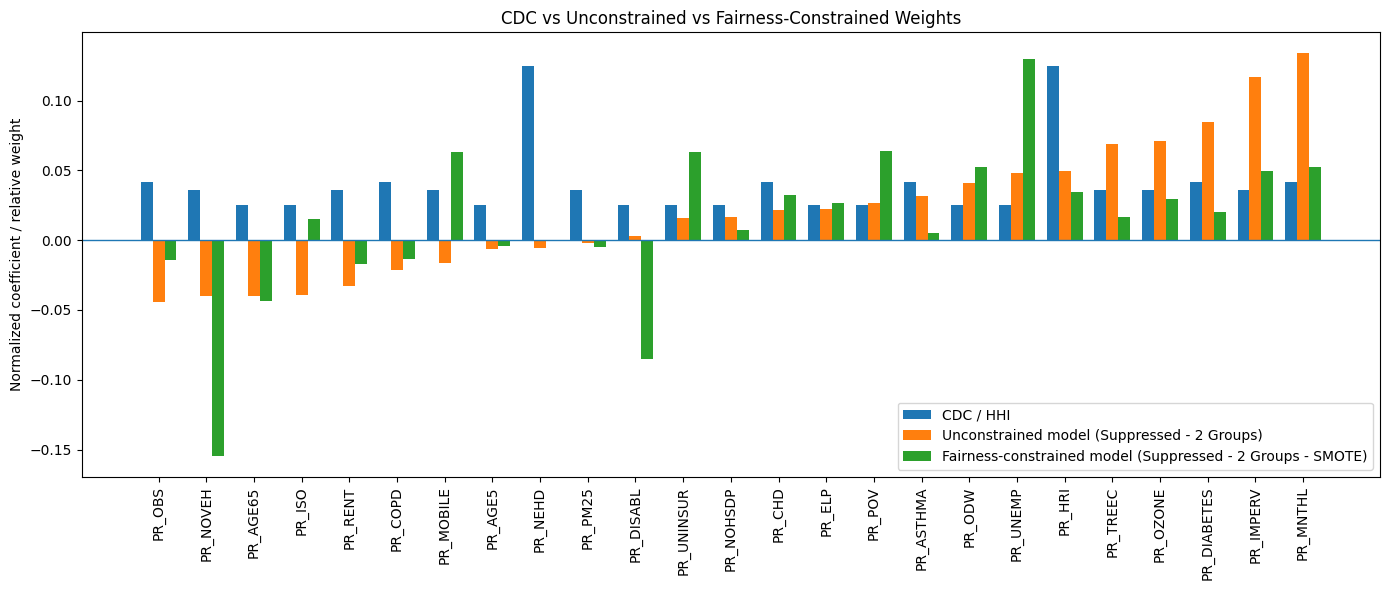

In [9]:
# plot

import matplotlib.pyplot as plt

plot_df = coef_df.sort_values("unconstrained_weight")
x = np.arange(len(plot_df))

plt.figure(figsize=(14, 6))

plt.bar(
    x - 0.25,
    plot_df["cdc_weight"],
    width=0.25,
    label="CDC / HHI"
)

plt.bar(
    x,
    plot_df["unconstrained_weight"],
    width=0.25,
    label="Unconstrained model (Suppressed - 2 Groups)"
)

plt.bar(
    x + 0.25,
    plot_df["constrained_weight"],
    width=0.25,
    label="Fairness-constrained model (Suppressed - 2 Groups - SMOTE)"
)

plt.axhline(0, linewidth=1)
plt.xticks(x, plot_df["indicator"], rotation=90)
plt.ylabel("Normalized coefficient / relative weight")
plt.title("CDC vs Unconstrained vs Fairness-Constrained Weights")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# summary table

summary_table = coef_df[[
    "indicator",
    "cdc_weight",
    "unconstrained_weight",
    "constrained_weight",
    "unconstrained_minus_cdc",
    "constrained_minus_unconstrained"
]].copy()

summary_table = summary_table.sort_values(
    "unconstrained_minus_cdc",
    key=lambda s: s.abs(),
    ascending=False
)

summary_table.head(10)

,indicator,cdc_weight,unconstrained_weight,constrained_weight,unconstrained_minus_cdc,constrained_minus_unconstrained
0,PR_NEHD,0.124988,-0.005886,0.000193,-0.130873,0.006079
7,PR_MNTHL,0.041696,0.134360,0.052073,0.092665,-0.082287
3,PR_OBS,0.041696,-0.044179,-0.014031,-0.085875,0.030149
18,PR_IMPERV,0.035696,0.116758,0.049843,0.081062,-0.066915
20,PR_NOVEH,0.035696,-0.040299,-0.154941,-0.075995,-0.114642
1,PR_HRI,0.124988,0.049738,0.034464,-0.075249,-0.015274
22,PR_RENT,0.035696,-0.032786,-0.017437,-0.068483,0.015349
16,PR_AGE65,0.024998,-0.039788,-0.043926,-0.064786,-0.004137
12,PR_ISO,0.024998,-0.039318,0.014962,-0.064316,0.054280
5,PR_COPD,0.041696,-0.021714,-0.013658,-0.063409,0.008055


In [11]:
summary_table2 = summary_table.sort_values(
    "constrained_minus_unconstrained",
    key=lambda s: s.abs(),
    ascending=False
)

summary_table2.head(10)

,indicator,cdc_weight,unconstrained_weight,constrained_weight,unconstrained_minus_cdc,constrained_minus_unconstrained
20,PR_NOVEH,0.035696,-0.040299,-0.154941,-0.075995,-0.114642
14,PR_DISABL,0.024998,0.002919,-0.085357,-0.022078,-0.088276
7,PR_MNTHL,0.041696,0.134360,0.052073,0.092665,-0.082287
10,PR_UNEMP,0.024998,0.047941,0.129773,0.022943,0.081833
21,PR_MOBILE,0.035696,-0.016029,0.062970,-0.051725,0.078998
18,PR_IMPERV,0.035696,0.116758,0.049843,0.081062,-0.066915
4,PR_DIABETES,0.041696,0.084660,0.020112,0.042964,-0.064548
12,PR_ISO,0.024998,-0.039318,0.014962,-0.064316,0.054280
19,PR_TREEC,0.035696,0.068656,0.016402,0.032960,-0.052254
8,PR_UNINSUR,0.024998,0.015902,0.063104,-0.009096,0.047202
